In [53]:
# ============================================================
# LIBRARIES & DISPLAY SETTINGS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    rankdata
)
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [54]:
# ============================================================
# H3 — LOAD AGE_SEX DATA
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-"
    r"\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-"
    r"\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"
)

AGE_SEX_SHEET = "Age_Sex"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"\nWorkbook not found:\n{INPUT_FILE}\n"
        "Please check the file path."
    )

age_sex_df = pd.read_excel(
    INPUT_FILE,
    sheet_name=AGE_SEX_SHEET
)

print("=" * 80)
print("H3 AGE_SEX DATA")
print("=" * 80)

print(f"Rows loaded: {len(age_sex_df):,}")
print(f"Columns    : {list(age_sex_df.columns)}")

display(age_sex_df.head())

H3 AGE_SEX DATA
Rows loaded: 190
Columns    : ['fiscal_year', 'fiscal_year_start', 'sex', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours']


,fiscal_year,fiscal_year_start,sex,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2003-2004,2003,Female,0–17,Pediatric Population,611154,101,1.6800
1,2003-2004,2003,Female,18–34,Young Adult Population,532768,127,2.1200
2,2003-2004,2003,Female,35–49,Adult Population,503478,129,2.1500
3,2003-2004,2003,Female,50–64,Pre-Senior Population,349504,141,2.3500
4,2003-2004,2003,Female,65–85+,Geriatric Population,478789,203,3.3800


In [55]:
# ============================================================
# STANDARDIZE COLUMN NAMES & VALIDATE REQUIRED COLUMNS
# ============================================================

age_sex_df.columns = (
    age_sex_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

REQUIRED_COLUMNS = [
    "fiscal_year",
    "fiscal_year_start",
    "age_group",
    "ed_visits",
    "median_los_minutes"
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in age_sex_df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required H3 columns: "
        + ", ".join(missing_columns)
    )

print("=" * 80)
print("REQUIRED COLUMNS VALIDATION")
print("=" * 80)
for col in REQUIRED_COLUMNS:
    print(f"  ✓ {col}")

REQUIRED COLUMNS VALIDATION
  ✓ fiscal_year
  ✓ fiscal_year_start
  ✓ age_group
  ✓ ed_visits
  ✓ median_los_minutes


In [56]:
# ============================================================
# CLEAN NUMERIC VARIABLES & STANDARDIZE AGE GROUPS
# ============================================================

AGE_GROUPS = [
    "Pediatric & Youth",
    "Young Adult",
    "Middle Adult",
    "Older Adult"
]

def standardize_age_group(value):
    value_lower = str(value).strip().lower()

    if (
        "0-19" in value_lower
        or "0–19" in value_lower
        or "pediatric" in value_lower
        or "youth" in value_lower
        or "0-17" in value_lower
        or "0–17" in value_lower
    ):
        return "Pediatric & Youth"

    if (
        "20-44" in value_lower
        or "20–44" in value_lower
        or "young adult" in value_lower
        or "18-34" in value_lower
        or "18–34" in value_lower
    ):
        return "Young Adult"

    if (
        "45-64" in value_lower
        or "45–64" in value_lower
        or "middle adult" in value_lower
        or "35-49" in value_lower
        or "35–49" in value_lower
        or "50-64" in value_lower
        or "50–64" in value_lower
        or "adult" in value_lower
        or "pre-senior" in value_lower
    ):
        return "Middle Adult"

    if (
        "65+" in value_lower
        or "65 +" in value_lower
        or "older adult" in value_lower
        or "65-85" in value_lower
        or "65–85" in value_lower
        or "geriatric" in value_lower
    ):
        return "Older Adult"

    return np.nan

cleaned_df = age_sex_df.copy()

cleaned_df["fiscal_year_start"] = pd.to_numeric(
    cleaned_df["fiscal_year_start"],
    errors="coerce"
)

cleaned_df["median_los_minutes"] = pd.to_numeric(
    cleaned_df["median_los_minutes"],
    errors="coerce"
)

cleaned_df["ed_visits"] = pd.to_numeric(
    cleaned_df["ed_visits"],
    errors="coerce"
)

cleaned_df = cleaned_df[
    cleaned_df["median_los_minutes"].notna()
].copy()

cleaned_df = cleaned_df[
    cleaned_df["median_los_minutes"] >= 0
].copy()

cleaned_df["age_group"] = (
    cleaned_df["age_group"]
    .apply(standardize_age_group)
)

cleaned_df = cleaned_df[
    cleaned_df["age_group"].isin(AGE_GROUPS)
].copy()

# Aggregate across demographic sub-strata (e.g. sex) to produce matched fiscal-year observations
h3_df = (
    cleaned_df
    .groupby(["fiscal_year", "fiscal_year_start", "age_group"], observed=True)
    .agg(
        median_los_minutes=("median_los_minutes", "median"),
        ed_visits=("ed_visits", "sum")
    )
    .reset_index()
)

print("=" * 80)
print("H3 CLEANED DATASET SUMMARY")
print("=" * 80)
print(f"Total matched observations : {len(h3_df):,}")
print(f"Fiscal years covered       : {h3_df['fiscal_year_start'].nunique()}")
print(f"Age groups covered         : {h3_df['age_group'].nunique()}")
display(h3_df.head(8))

H3 CLEANED DATASET SUMMARY
Total matched observations : 76
Fiscal years covered       : 19
Age groups covered         : 4


,fiscal_year,fiscal_year_start,age_group,median_los_minutes,ed_visits
0,2003-2004,2003,Middle Adult,134.5000,1713487
1,2003-2004,2003,Older Adult,195.5000,875580
2,2003-2004,2003,Pediatric & Youth,101.0000,1313386
3,2003-2004,2003,Young Adult,120.5000,1003941
4,2004-2005,2004,Middle Adult,138.5000,1867241
5,2004-2005,2004,Older Adult,198.0000,961393
6,2004-2005,2004,Pediatric & Youth,106.0000,1348769
7,2004-2005,2004,Young Adult,125.5000,1070402


In [57]:
# ============================================================
# H3 — STRUCTURE VALIDATION
# ============================================================

age_year_check = (
    h3_df
    .groupby(
        [
            "fiscal_year_start",
            "age_group"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=AGE_GROUPS,
        fill_value=0
    )
)

print("=" * 80)
print("H3 AGE GROUP × FISCAL YEAR STRUCTURE")
print("=" * 80)

display(age_year_check)

age_count_by_year = (
    age_year_check
    .gt(0)
    .sum(axis=1)
)

display(
    age_count_by_year.to_frame(
        "Age_Groups_Present"
    )
)

print(f"\nMinimum age groups present per fiscal year: {age_count_by_year.min()}")
print(f"Maximum age groups present per fiscal year: {age_count_by_year.max()}")

if not (age_count_by_year == len(AGE_GROUPS)).all():
    incomplete_years = (
        age_count_by_year[
            age_count_by_year != len(AGE_GROUPS)
        ]
    )
    raise ValueError(
        "Every fiscal year used by H3 must contain all four age groups.\n"
        f"Incomplete years:\n{incomplete_years}"
    )

print("\nStructure validation passed: All fiscal years contain all 4 age groups.")

H3 AGE GROUP × FISCAL YEAR STRUCTURE


age_group,Pediatric & Youth,Young Adult,Middle Adult,Older Adult
fiscal_year_start,,,,
2003,1,1,1,1
2004,1,1,1,1
2005,1,1,1,1
2006,1,1,1,1
2007,1,1,1,1
2008,1,1,1,1
2009,1,1,1,1
2010,1,1,1,1
2011,1,1,1,1


,Age_Groups_Present
fiscal_year_start,
2003,4
2004,4
2005,4
2006,4
2007,4
2008,4
2009,4
2010,4
2011,4



Minimum age groups present per fiscal year: 4
Maximum age groups present per fiscal year: 4

Structure validation passed: All fiscal years contain all 4 age groups.


In [58]:
# ============================================================
# H3 — DUPLICATE CHECK
# ============================================================

duplicate_mask = (
    h3_df
    .duplicated(
        subset=[
            "fiscal_year_start",
            "age_group"
        ],
        keep=False
    )
)

duplicate_count = duplicate_mask.sum()

print("=" * 80)
print("H3 DUPLICATE RECORD VALIDATION")
print("=" * 80)

print(f"Duplicate fiscal-year × age-group records: {duplicate_count:,}")

if duplicate_count > 0:
    raise ValueError(
        "Duplicate fiscal-year × age-group records detected. "
        "Resolve the source structure before running H3."
    )

print("Validation passed: Exactly 0 duplicate records.")

H3 DUPLICATE RECORD VALIDATION
Duplicate fiscal-year × age-group records: 0
Validation passed: Exactly 0 duplicate records.


In [59]:
# ============================================================
# H3 — CREATE MATCHED FRIEDMAN MATRIX
# ============================================================

friedman_matrix = (
    h3_df
    .pivot(
        index="fiscal_year_start",
        columns="age_group",
        values="median_los_minutes"
    )
    .reindex(
        columns=AGE_GROUPS
    )
    .sort_index()
)

complete_matrix = (
    friedman_matrix
    .dropna(
        how="any"
    )
)

print("=" * 80)
print("H3 FRIEDMAN MATRIX")
print("=" * 80)

print(f"Matrix shape                    : {friedman_matrix.shape}")
print(f"Complete matched fiscal-year blocks: {len(complete_matrix):,}")

if len(complete_matrix) < 2:
    raise ValueError(
        "Not enough complete fiscal-year blocks for the Friedman test."
    )

display(complete_matrix)

H3 FRIEDMAN MATRIX
Matrix shape                    : (19, 4)
Complete matched fiscal-year blocks: 19


age_group,Pediatric & Youth,Young Adult,Middle Adult,Older Adult
fiscal_year_start,,,,
2003,101.0000,120.5000,134.5000,195.5000
2004,106.0000,125.5000,138.5000,198.0000
2005,110.0000,129.5000,142.5000,201.0000
2006,112.0000,133.5000,147.0000,206.5000
2007,117.0000,138.5000,154.5000,231.5000
2008,122.5000,142.0000,161.0000,243.0000
2009,125.0000,143.5000,162.5000,244.5000
2010,117.0000,136.0000,153.5000,231.0000
2011,116.0000,138.5000,157.0000,234.0000


In [60]:
# ============================================================
# H3 — PRIMARY FRIEDMAN TEST
# ============================================================

ALPHA = 0.05

friedman_statistic, p_value = friedmanchisquare(
    *[
        complete_matrix[
            age_group
        ].to_numpy()
        for age_group in AGE_GROUPS
    ]
)

degrees_of_freedom = (
    len(AGE_GROUPS) - 1
)

print("=" * 80)
print("H3 — FRIEDMAN TEST")
print("=" * 80)

print(f"Friedman χ²       : {friedman_statistic:.6f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value           : {p_value:.10g}")
print(f"Alpha (α)         : {ALPHA}")

H3 — FRIEDMAN TEST
Friedman χ²       : 57.000000
Degrees of freedom: 3
P-value           : 2.569880219e-12
Alpha (α)         : 0.05


In [61]:
# ============================================================
# H3 — KENDALL'S W EFFECT SIZE
# ============================================================

n_blocks = len(complete_matrix)
k_groups = len(AGE_GROUPS)

kendalls_w = (
    friedman_statistic
    / (
        n_blocks
        * (k_groups - 1)
    )
)

print("=" * 80)
print("H3 EFFECT SIZE — KENDALL'S W")
print("=" * 80)

print(f"Matched blocks (N) : {n_blocks}")
print(f"Age groups (k)     : {k_groups}")
print(f"Kendall's W        : {kendalls_w:.6f}")
print(f"W in [0, 1]        : {0 <= kendalls_w <= 1}")

H3 EFFECT SIZE — KENDALL'S W
Matched blocks (N) : 19
Age groups (k)     : 4
Kendall's W        : 1.000000
W in [0, 1]        : True


In [62]:
# ============================================================
# H3 — HYPOTHESIS DECISION
# ============================================================

if p_value < ALPHA:
    decision = "Reject H₀"
    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED LOS differs across "
        "the four age groups within the matched "
        "fiscal-year aggregate data."
    )
else:
    decision = "Fail to Reject H₀"
    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED LOS differs "
        "across the four age groups within the matched "
        "fiscal-year aggregate data."
    )

print("=" * 80)
print("H3 HYPOTHESIS DECISION")
print("=" * 80)

print(f"Decision   : {decision}")
print(f"\nConclusion :\n{conclusion}")

H3 HYPOTHESIS DECISION
Decision   : Reject H₀

Conclusion :
There is statistically significant evidence that reported median ED LOS differs across the four age groups within the matched fiscal-year aggregate data.


In [63]:
# ============================================================
# H3 — POST-HOC ANALYSIS (WILCOXON SIGNED-RANK WITH BONFERRONI)
# ============================================================

pairwise_results = []

if p_value < ALPHA:
    for group1, group2 in combinations(AGE_GROUPS, 2):
        statistic, raw_p = wilcoxon(
            complete_matrix[group1],
            complete_matrix[group2],
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )
        pairwise_results.append({
            "Group_1": group1,
            "Group_2": group2,
            "Wilcoxon_Statistic": statistic,
            "Raw_P_Value": raw_p
        })

posthoc = pd.DataFrame(pairwise_results)

if not posthoc.empty:
    number_comparisons = len(posthoc)
    posthoc["Adjusted_P_Value"] = (
        posthoc["Raw_P_Value"] * number_comparisons
    ).clip(upper=1)

    posthoc["Significant"] = (
        posthoc["Adjusted_P_Value"] < ALPHA
    )

    posthoc = (
        posthoc
        .sort_values("Adjusted_P_Value")
        .reset_index(drop=True)
    )

    print("=" * 80)
    print("H3 POST-HOC PAIRWISE COMPARISONS (BONFERRONI-CORRECTED)")
    print("=" * 80)
    display(posthoc.round(6))

    if len(posthoc) != 6:
        raise ValueError(
            "Four age groups require exactly six pairwise comparisons."
        )
else:
    posthoc = pd.DataFrame(
        columns=[
            "Group_1",
            "Group_2",
            "Wilcoxon_Statistic",
            "Raw_P_Value",
            "Adjusted_P_Value",
            "Significant"
        ]
    )
    print("Friedman test was not significant; post-hoc comparisons were not performed.")

H3 POST-HOC PAIRWISE COMPARISONS (BONFERRONI-CORRECTED)


,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,Pediatric & Youth,Young Adult,0.0000,0.0001,0.0008,True
1,Young Adult,Middle Adult,0.0000,0.0001,0.0008,True
2,Middle Adult,Older Adult,0.0000,0.0001,0.0008,True
3,Young Adult,Older Adult,0.0000,0.0001,0.0008,True
4,Pediatric & Youth,Older Adult,0.0000,0.0001,0.0008,True
5,Pediatric & Youth,Middle Adult,0.0000,0.0001,0.0008,True


In [64]:
# ============================================================
# H3 — DESCRIPTIVE SUMMARY TABLE
# ============================================================

h3_summary = (
    h3_df
    .groupby(
        "age_group",
        observed=True
    )
    .agg(
        Median_Reported_LOS=(
            "median_los_minutes",
            "median"
        ),
        Mean_Reported_LOS=(
            "median_los_minutes",
            "mean"
        ),
        Aggregate_Visits=(
            "ed_visits",
            "sum"
        ),
        Fiscal_Years=(
            "fiscal_year_start",
            "nunique"
        )
    )
    .reindex(
        AGE_GROUPS
    )
    .reset_index()
)

print("=" * 80)
print("H3 DESCRIPTIVE SUMMARY")
print("=" * 80)
display(h3_summary.round(2))

H3 DESCRIPTIVE SUMMARY


,age_group,Median_Reported_LOS,Mean_Reported_LOS,Aggregate_Visits,Fiscal_Years
0,Pediatric & Youth,121.5000,124.5500,38908652,19
1,Young Adult,142.0000,147.6300,36468069,19
2,Middle Adult,161.5000,167.5000,63172527,19
3,Older Adult,243.0000,244.1800,37213696,19


In [65]:
# ============================================================
# H3 — ESTIMATED RESOURCE BURDEN INDEX (ERBI)
# ============================================================
# NOTE: ERBI is a resource-burden proxy (ED Visits × Reported Median LOS).
# It is NOT actual total ED minutes or patient-level utilization time.

h3_df["ERBI"] = (
    h3_df["ed_visits"]
    * h3_df["median_los_minutes"]
)

print("ERBI calculated in-memory as a resource-burden proxy.")

ERBI calculated in-memory as a resource-burden proxy.


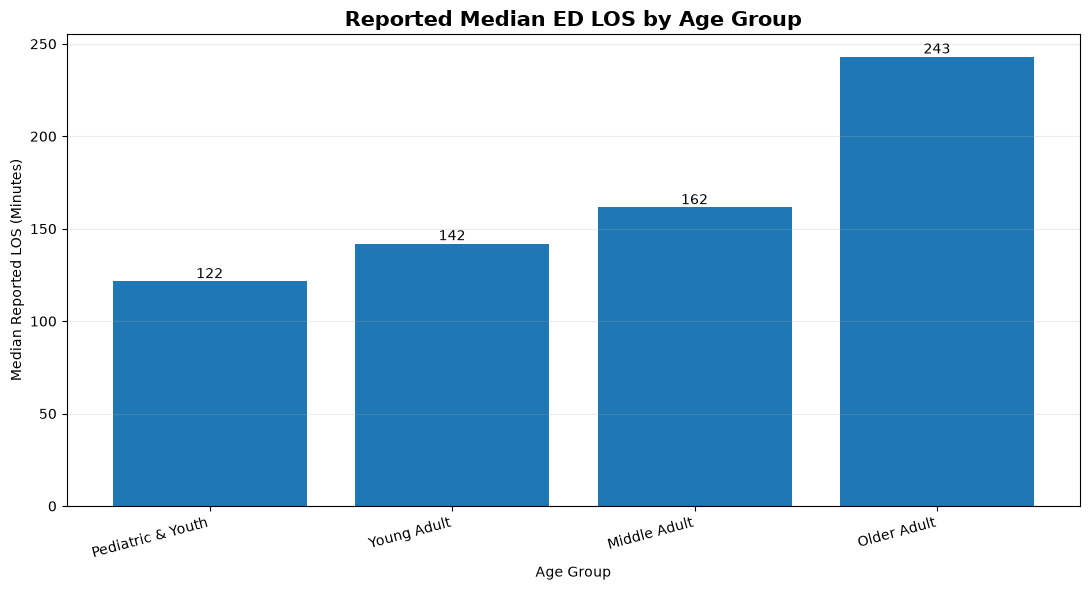

In [66]:
# ============================================================
# H3 VISUAL 1 — REPORTED MEDIAN ED LOS BY AGE GROUP
# ============================================================

plot_data = (
    h3_summary
    .set_index("age_group")
    .reindex(AGE_GROUPS)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    AGE_GROUPS,
    plot_data["Median_Reported_LOS"],
    color="#1f77b4"
)

plt.title(
    "Reported Median ED LOS by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Median Reported LOS (Minutes)")
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, plot_data["Median_Reported_LOS"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

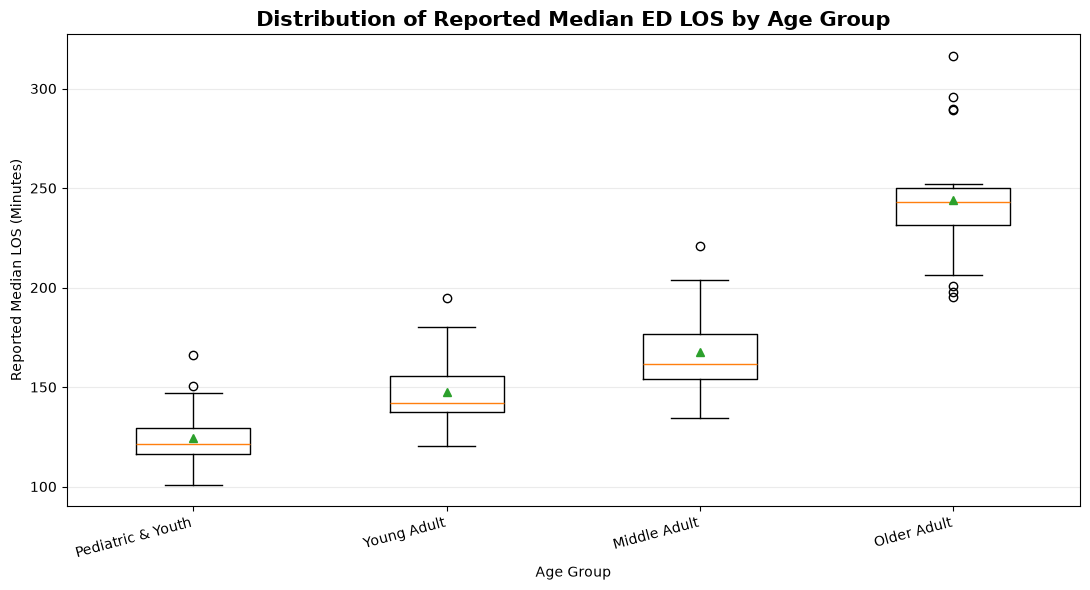

In [67]:
# ============================================================
# H3 VISUAL 2 — DISTRIBUTION OF REPORTED MEDIAN ED LOS BY AGE GROUP
# ============================================================

box_data = [
    h3_df.loc[
        h3_df["age_group"] == age_group,
        "median_los_minutes"
    ].dropna().to_numpy()
    for age_group in AGE_GROUPS
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    box_data,
    tick_labels=AGE_GROUPS,
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Reported Median LOS (Minutes)")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

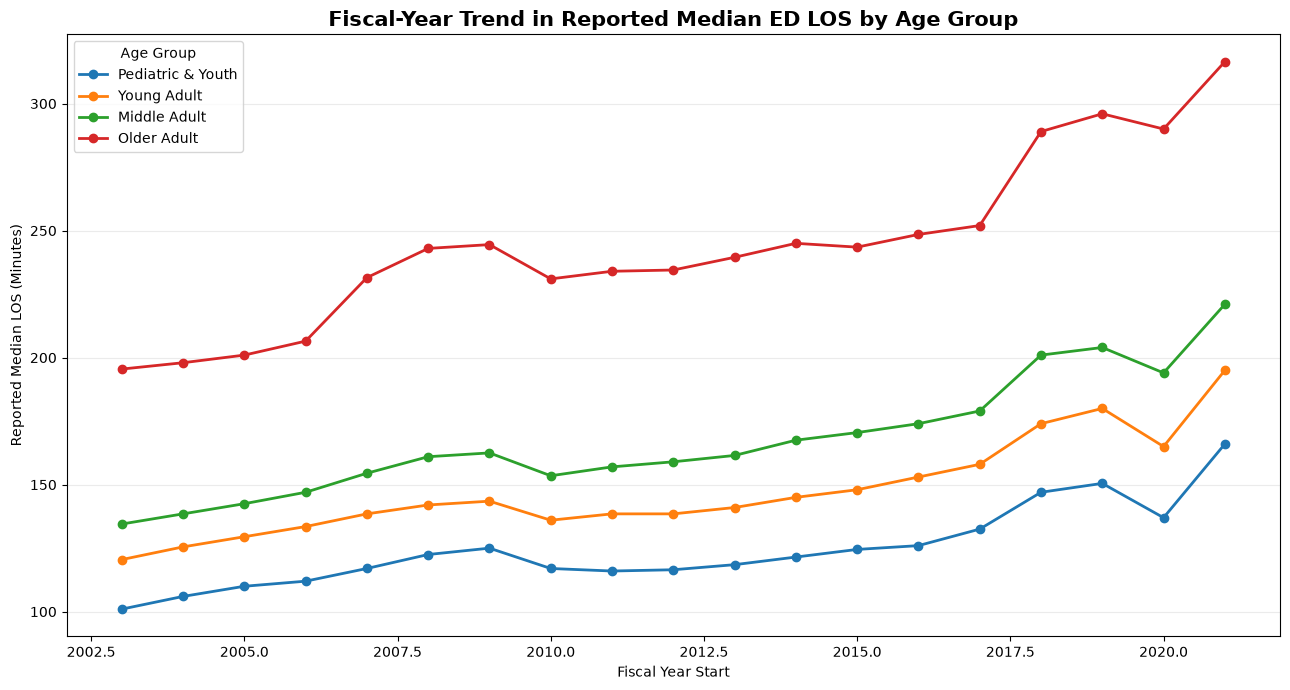

In [68]:
# ============================================================
# H3 VISUAL 3 — FISCAL-YEAR TREND BY AGE GROUP
# ============================================================

year_age = (
    h3_df
    .groupby(
        [
            "fiscal_year_start",
            "age_group"
        ],
        observed=True
    )[
        "median_los_minutes"
    ]
    .median()
    .reset_index()
)

plt.figure(figsize=(13, 7))

for age_group in AGE_GROUPS:
    subset = year_age[
        year_age["age_group"] == age_group
    ].sort_values("fiscal_year_start")

    plt.plot(
        subset["fiscal_year_start"],
        subset["median_los_minutes"],
        marker="o",
        linewidth=2,
        label=age_group
    )

plt.title(
    "Fiscal-Year Trend in Reported Median ED LOS by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fiscal Year Start")
plt.ylabel("Reported Median LOS (Minutes)")
plt.legend(title="Age Group")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

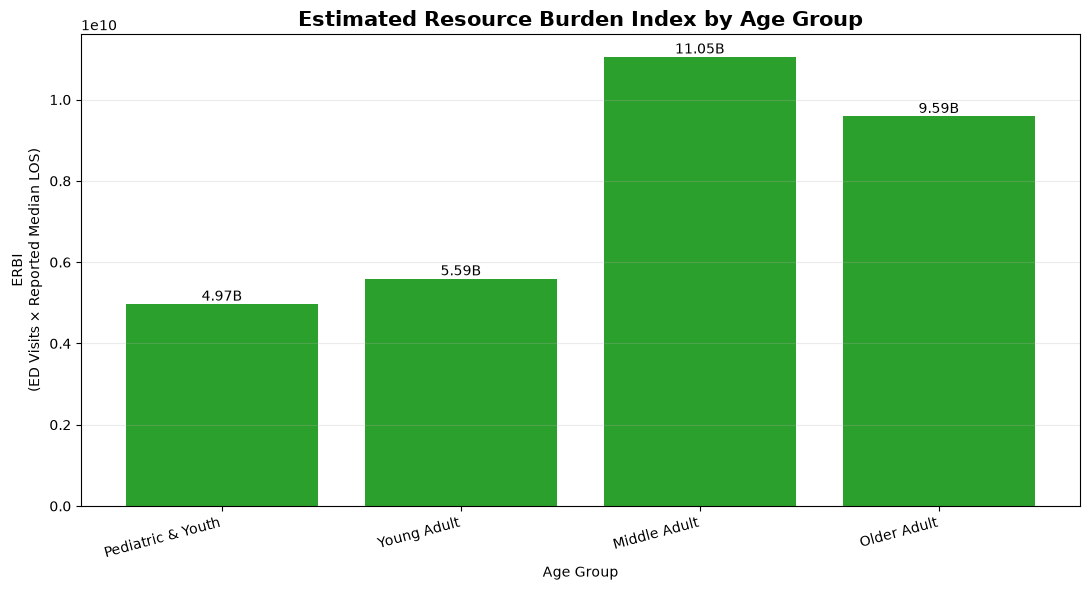

In [69]:
# ============================================================
# H3 VISUAL 4 — ESTIMATED RESOURCE BURDEN INDEX BY AGE GROUP
# ============================================================

erbi_summary = (
    h3_df
    .groupby(
        "age_group",
        observed=True
    )[
        "ERBI"
    ]
    .sum()
    .reindex(
        AGE_GROUPS
    )
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    AGE_GROUPS,
    erbi_summary.values,
    color="#2ca02c"
)

plt.title(
    "Estimated Resource Burden Index by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("ERBI\n(ED Visits × Reported Median LOS)")
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, erbi_summary.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1e9:.2f}B",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# H3 — FINAL RESULTS TABLE
# ============================================================

h3_results = pd.DataFrame({
    "Hypothesis": [
        "H3"
    ],
    "Research_Question": [
        "Does reported median ED LOS differ across age groups within the matched fiscal-year aggregate data?"
    ],
    "Primary_Test": [
        "Friedman test"
    ],
    "Matched_Blocks": [
        len(complete_matrix)
    ],
    "Age_Groups": [
        len(AGE_GROUPS)
    ],
    "Friedman_Statistic": [
        friedman_statistic
    ],
    "Degrees_of_Freedom": [
        degrees_of_freedom
    ],
    "P_Value": [
        p_value
    ],
    "Alpha": [
        ALPHA
    ],
    "Kendalls_W": [
        kendalls_w
    ],
    "Decision": [
        decision
    ]
})

print("=" * 90)
print("H3 — FINAL RESULTS TABLE")
print("=" * 90)
display(h3_results.round(6))

H3 — FINAL RESULTS TABLE


,Hypothesis,Research_Question,Primary_Test,Matched_Blocks,Age_Groups,Friedman_Statistic,Degrees_of_Freedom,P_Value,Alpha,Kendalls_W,Decision
0,H3,Does reported median ED LOS differ across age ...,Friedman test,19,4,57.0000,3,0.0000,0.0500,1.0000,Reject H₀


In [71]:
# ============================================================
# H3 — FINAL INTERPRETATION
# ============================================================

print("=" * 90)
print("H3 — FINAL HYPOTHESIS TEST RESULT")
print("=" * 90)

print("\nResearch Question:")
print(
    "Does reported median ED LOS differ across age groups "
    "within the matched fiscal-year aggregate data?"
)

print("\nPrimary Test:")
print("Friedman test on matched fiscal-year blocks.")

print(f"\nFriedman χ² = {friedman_statistic:.4f}")
print(f"df          = {degrees_of_freedom}")
print(f"p           = {p_value:.10g}")
print(f"Kendall's W = {kendalls_w:.4f}")

print(f"\nDecision: {decision}")
print(f"\nConclusion:\n{conclusion}")

if p_value < ALPHA:
    print("\nPost-hoc method:")
    print("Wilcoxon signed-rank pairwise comparisons with Bonferroni correction.")
    print(f"Pairwise comparisons: {len(posthoc)}")

print("\nMethodological limitation:")
print(
    "The analysis uses pre-aggregated aggregate observations. "
    "The matched blocks represent fiscal-year age-group "
    "combinations rather than individual patients. "
    "Therefore, findings represent aggregate-level associations "
    "and should not be interpreted as individual-patient effects "
    "or causal relationships."
)

H3 — FINAL HYPOTHESIS TEST RESULT

Research Question:
Does reported median ED LOS differ across age groups within the matched fiscal-year aggregate data?

Primary Test:
Friedman test on matched fiscal-year blocks.

Friedman χ² = 57.0000
df          = 3
p           = 2.569880219e-12
Kendall's W = 1.0000

Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED LOS differs across the four age groups within the matched fiscal-year aggregate data.

Post-hoc method:
Wilcoxon signed-rank pairwise comparisons with Bonferroni correction.
Pairwise comparisons: 6

Methodological limitation:
The analysis uses pre-aggregated aggregate observations. The matched blocks represent fiscal-year age-group combinations rather than individual patients. Therefore, findings represent aggregate-level associations and should not be interpreted as individual-patient effects or causal relationships.


In [76]:
# ============================================================
# H3 — AGGREGATE STRUCTURE VALIDATION SUMMARY
# ============================================================

print("=" * 80)
print("H3 AGGREGATE STRUCTURE VALIDATION SUMMARY")
print("=" * 80)

print(f"Total matched blocks (Fiscal Years) : {len(complete_matrix):,}")
print(f"Age groups per block                : {len(AGE_GROUPS)}")
print(f"Friedman matrix shape               : {complete_matrix.shape}")
print(f"Friedman chi-square (χ²)            : {friedman_statistic:.4f}")
print(f"Degrees of freedom (df)             : {degrees_of_freedom}")
print(f"p-value                             : {p_value:.10g}")
print(f"Kendall's W                         : {kendalls_w:.4f}")
print(f"Decision                            : {decision}")
print(f"Post-hoc pairwise comparisons       : {len(posthoc):,}")
if not posthoc.empty:
    sig_count = posthoc['Significant'].sum()
    print(f"Significant pairs (Bonferroni)      : {sig_count:,} of {len(posthoc):,}")

H3 AGGREGATE STRUCTURE VALIDATION SUMMARY
Total matched blocks (Fiscal Years) : 19
Age groups per block                : 4
Friedman matrix shape               : (19, 4)
Friedman chi-square (χ²)            : 57.0000
Degrees of freedom (df)             : 3
p-value                             : 2.569880219e-12
Kendall's W                         : 1.0000
Decision                            : Reject H₀
Post-hoc pairwise comparisons       : 6
Significant pairs (Bonferroni)      : 6 of 6


In [77]:
# ============================================================
# H3 — VARIABLE SAFETY CHECK
# ============================================================

required_h3_variables = [
    "h3_df",
    "friedman_matrix",
    "complete_matrix",
    "friedman_statistic",
    "degrees_of_freedom",
    "p_value",
    "ALPHA",
    "kendalls_w",
    "decision",
    "conclusion",
    "h3_summary",
    "h3_results",
    "posthoc"
]

missing_variables = [
    variable
    for variable in required_h3_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following H3 variables are missing: "
        + ", ".join(missing_variables)
    )

print("=" * 80)
print("ALL REQUIRED H3 VARIABLES ARE DEFINED")
print("=" * 80)

for variable in required_h3_variables:
    print(f"  ✓ {variable}")

if p_value < ALPHA:
    if "posthoc" not in globals():
        raise NameError("Post-hoc results are missing.")
    if len(posthoc) != 6:
        raise ValueError("Expected six H3 pairwise comparisons.")
    print("\n  ✓ Post-hoc validation passed: Exactly 6 pairwise comparisons.")

ALL REQUIRED H3 VARIABLES ARE DEFINED
  ✓ h3_df
  ✓ friedman_matrix
  ✓ complete_matrix
  ✓ friedman_statistic
  ✓ degrees_of_freedom
  ✓ p_value
  ✓ ALPHA
  ✓ kendalls_w
  ✓ decision
  ✓ conclusion
  ✓ h3_summary
  ✓ h3_results
  ✓ posthoc

  ✓ Post-hoc validation passed: Exactly 6 pairwise comparisons.
